# Helper Functions

In [51]:
import os
import re
from datetime import datetime
import pandas as pd

# ========================================
# CHOOSE YOUR PROVIDER AND PASTE API KEY
# ========================================
PROVIDER = "gemini"  # Options: "claude" or "gemini"

CLAUDE_API_KEY = "YOUR_CLAUDE_KEY_HERE"  # Get from: https://console.anthropic.com/
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]  # Get from: https://aistudio.google.com/app/apikey

# ========================================

# Setup based on provider
if PROVIDER == "claude":
    import anthropic
    client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)
    print("✅ Using Claude (Anthropic)")
    print("   Model: claude-3-haiku-20240307")
    
elif PROVIDER == "gemini":
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)
    #client = genai.GenerativeModel('models/gemini-3.1-flash-lite-preview')
    client = genai.GenerativeModel('models/gemini-3-flash-preview')
    #client = genai.GenerativeModel('models/gemini-2.5-flash')
    print("✅ Using Gemini")
    print("   ⚠️  Note: Only 20 requests/day on free tier")


✅ Using Gemini
   ⚠️  Note: Only 20 requests/day on free tier


In [52]:
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_llm_forecast_48h(df, Turb_ID, base_day, output):
    """
    Evaluates a 48-hour (288 point) forecast.
    Always compares against Day base_day+14 and base_day+15.
    """

    # 1. Define 48-hour target window
    target_start = base_day + 14
    target_end = base_day + 15

    # 2. Extract actual data (chronological order)
    actual_data = df[
        (df['TurbID'] == Turb_ID) &
        (df['Day'] >= target_start) &
        (df['Day'] <= target_end)
    ]

    actual_values = (
        actual_data
        .sort_values(['Day', 'Tmstamp'])
        ['Patv']
        .dropna()
        .tolist()
    )

    # Parsing of LLM output
    try:
        predicted_values = [
            float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", output)
        ]
    except Exception:
        print("Error: Could not parse LLM output.")
        return None

    # Check expected length (288 points)
    if len(predicted_values) != 288:
        print(f"Warning: Expected 288 predictions, got {len(predicted_values)}")

    if len(actual_values) != 288:
        print(f"Warning: Expected 288 actual points, got {len(actual_values)}")

    # Align lengths safely
    min_len = min(len(actual_values), len(predicted_values))

    if min_len == 0:
        print("Error: No overlapping forecast points.")
        return None

    y_true = actual_values[:min_len]
    y_pred = predicted_values[:min_len]

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = (mae + rmse) /2

    print(f"\n--- 48-Hour Evaluation (Days {target_start}-{target_end}) ---")
    print(f"Points used: {min_len}/288")
    print(f"MAE:  {mae:.2f} kW")
    print(f"RMSE: {rmse:.2f} kW")
    print(f"Score: {score:.2f} kW")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Score": score,
        "points_used": min_len
    }

In [53]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_llm_predictions_vs_ground_truth(
    data_df: pd.DataFrame,    # Pass the actual DataFrame here
    llm_responses,           # List of raw string responses from the LLM
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 2,
    labels=None,
    title=None,
    clip=(0.0, 1500.0),
    hour_tick: float = 2.0,
    legend_alpha: float = 0.75,
    show=True,
):
    # --- 1. Handle Inputs ---
    if labels is None:
        labels = [f"LLM Prediction {i+1}" for i in range(len(llm_responses))]
    
    # --- 2. Ground Truth Extraction ---
    expected_len = 144 * horizon_days
    target_days = list(range(forecast_day, forecast_day + horizon_days))
    
    gt = data_df[(data_df["TurbID"] == turb_id) & (data_df["Day"].isin(target_days))].copy()
    if gt.empty:
        raise ValueError(f"No ground-truth found for TurbID {turb_id} on days {target_days}")

    gt = gt.sort_values(["Day", "Tmstamp"]) if "Tmstamp" in gt.columns else gt.sort_values(["Day"])
    
    y_true = gt["Patv"].to_numpy(dtype=float)
    if len(y_true) < expected_len:
         # Pad or truncate if data is slightly off, but warn user
         print(f"Warning: GT length {len(y_true)} vs expected {expected_len}")
    
    y_true = np.clip(y_true[:expected_len], clip[0], clip[1])

    # --- 3. Setup Plot ---
    x_hours = np.arange(len(y_true)) / 6.0
    fig, ax = plt.subplots(figsize=(12.5, 5))
    ax.plot(x_hours, y_true, linewidth=2.0, label="Ground truth", color='tab:blue')

    # --- 4. Parse and Plot LLM Responses ---
    for raw_response, lab in zip(llm_responses, labels):
        try:
            # Clean up potential markdown formatting
            clean_json = raw_response.replace("```json", "").replace("```", "").strip()
            data = json.loads(clean_json)
            y_pred = np.array(data["forecast"], dtype=float)
            
            if len(y_pred) != expected_len:
                print(f"Warning: {lab} returned {len(y_pred)} steps, expected {expected_len}")
            
            # Ensure length matches x_hours for plotting
            plot_len = min(len(y_pred), len(x_hours))
            y_pred_clipped = np.clip(y_pred[:plot_len], clip[0], clip[1])
            
            ax.plot(x_hours[:plot_len], y_pred_clipped, linewidth=1.5, linestyle="--", color="orange", label=lab)
            
        except Exception as e:
            print(f"Error parsing LLM response for {lab}: {e}")

    # --- 5. Formatting ---
    ax.set_xlim(0, 24 * horizon_days)
    ax.set_xticks(np.arange(0, (24 * horizon_days) + 1e-9, hour_tick))
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Patv (kW)")
    ax.grid(True, alpha=0.2)

    if title is None:
        title = f"TurbID={turb_id} | Day {forecast_day} | Horizon = 2 day(s)"
    ax.set_title(title)

    # Update this section in your plotting function
    ax.legend(
        loc="lower left",            # Anchors the legend to its bottom-left corner
        bbox_to_anchor=(0.02, 0.02), # Adds a small padding from the axes corner
        framealpha=legend_alpha,
        fontsize=10,
        borderpad=0.6,
        labelspacing=0.4,
        handlelength=2.2,
    )
    fig.tight_layout()
    
    if show:
        plt.show()
    return fig, ax

# Baseline Prompt

In [54]:
import pandas as pd

def call_llm_base(df, Turb_ID, base_day):
    turbine_data = df[df['TurbID'] == Turb_ID]
    # Drop rows where 'Wspd' (Wind Speed) is missing
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13
    window_data = turbine_data[(turbine_data['Day'] >= base_day) & 
                               (turbine_data['Day'] <= end_day)].drop(columns=['TurbID'])

    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
You have been provided with 14 days of sensor data for one Wind Turbine, starting from day {base_day} to day {end_day}. 

Input Data (last 14 days):
{data_str}

Task: Predict the 'Patv' (Active Power) for the NEXT 48 hours (Day {end_day + 2}). Do not write code. Return only a list containing exactly 288 numerical values (144 per day), representing 10-minute intervals.
"""
    
    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(prompt)
        return response.text

# Advanced Prompt

In [55]:
def call_llm_advanced(df, Turb_ID, base_day, feature_cols):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13

    required_cols = ['Day', 'Tmstamp'] + feature_cols

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ][required_cols].copy()


    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
Context: You are an expert wind turbine power forecasting model.

You are given 14 days of historical SCADA data for ONE turbine.
The data is sampled every 10 minutes (144 rows per day).
Columns provided: {', '.join(required_cols)}

Input Data:
{data_str}

Your task:
Predict the Active Power (Patv, in kW) for the NEXT 48 HOURS
(288 time steps at 10-minute resolution).

Instructions:

Learn the wind-speed to power relationship from the historical data.
Power is roughly proportional to wind speed cubed at low speeds.
Power saturates near rated power (~1500 kW).
Power is near zero at very low wind speeds.

Capture daily cyclic patterns.
Do NOT copy the last day.
Do NOT output negative values.
Clip values to the realistic range [0, 1500].

OUTPUT FORMAT REQUIREMENTS (CRITICAL):

Return valid JSON in the following format:

{{
  "forecast": [f1, f2, f3, ..., f288]
}}

The list MUST contain exactly 288 numbers.
If the list contains more or fewer values, the answer is invalid.

No text outside the JSON.
No explanations.
No markdown formatting.
Only raw JSON.
"""

    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt
        )
        return response.text

# Step 1: Load Data & Initialize Parameters

In [56]:
df = pd.read_csv('wtbdata_245days.csv')
feature_sets = {
    "all_features": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", 
                     "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
}

In [57]:
# Select from Turbines ID 1 - 134
Turbine = 1

# Select from Days 1 - 231 (There are 245 days total, but we need to leave room for the 14-day input window and 2-day forecast horizon)
Data_Start_Day = 2

# Decide which features to use for the LLM forecast
Used_Columns = feature_sets["all_features"]

# Used when plotting to indicate forecast start day on x-axis
Forecast_Day = Data_Start_Day + 14

# Step 2: Forecast with LLM Call

In [58]:
advanced_output = call_llm_advanced(df, Turb_ID=Turbine, base_day=Data_Start_Day, feature_cols=Used_Columns)

# Step 3: Calculate MAE, RMSE, and Score and Plot Results

In [59]:
print("LLM Response:")
print(advanced_output)
eval_results = evaluate_llm_forecast_48h(df, Turbine, Data_Start_Day, advanced_output)

LLM Response:
{
  "forecast": [
    125.0, 120.0, 115.0, 110.0, 105.0, 100.0, 95.0, 90.0, 100.0, 110.0, 125.0, 140.0, 160.0, 180.0, 205.0, 230.0, 260.0, 290.0,
    320.0, 350.0, 380.0, 410.0, 440.0, 470.0, 500.0, 520.0, 540.0, 560.0, 550.0, 530.0, 510.0, 490.0, 470.0, 450.0, 440.0, 435.0,
    430.0, 440.0, 460.0, 480.0, 510.0, 545.0, 580.0, 620.0, 660.0, 705.0, 750.0, 800.0, 850.0, 905.0, 960.0, 1010.0, 1060.0, 1110.0,
    1160.0, 1210.0, 1260.0, 1310.0, 1360.0, 1405.0, 1445.0, 1480.0, 1495.0, 1500.0, 1500.0, 1500.0, 1490.0, 1475.0, 1450.0, 1420.0, 1380.0, 1330.0,
    1280.0, 1220.0, 1160.0, 1100.0, 1040.0, 980.0, 920.0, 860.0, 800.0, 750.0, 700.0, 650.0, 600.0, 560.0, 520.0, 485.0, 450.0, 420.0,
    390.0, 365.0, 340.0, 315.0, 295.0, 275.0, 260.0, 245.0, 230.0, 215.0, 200.0, 190.0, 180.0, 175.0, 170.0, 165.0, 160.0, 155.0,
    150.0, 145.0, 140.0, 138.0, 135.0, 133.0, 130.0, 132.0, 135.0, 140.0, 148.0, 158.0, 170.0, 185.0, 200.0, 220.0, 240.0, 265.0,
    290.0, 320.0, 350.0, 385.0, 42

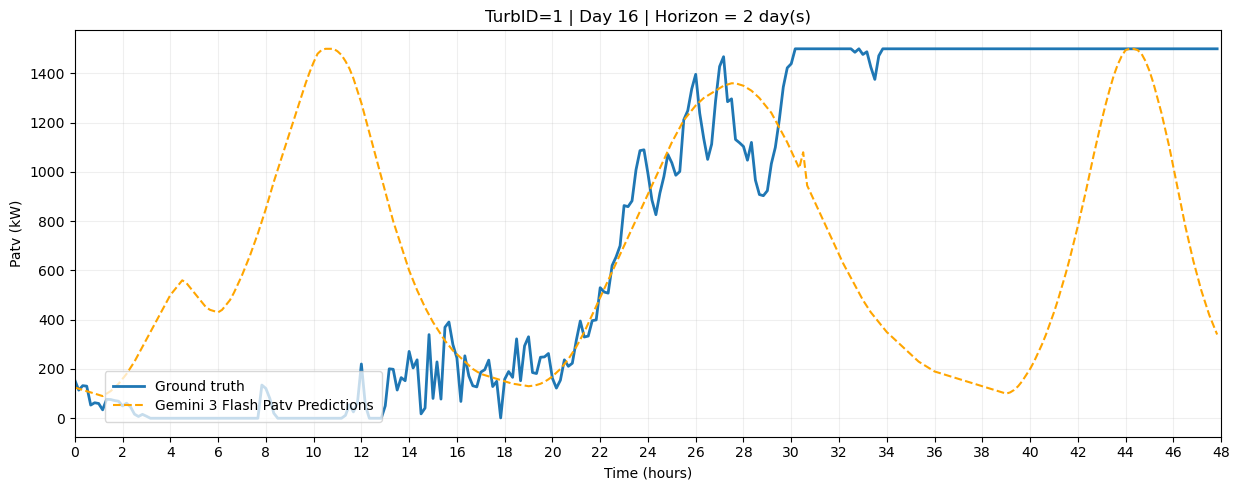

(<Figure size 1250x500 with 1 Axes>,
 <Axes: title={'center': 'TurbID=1 | Day 16 | Horizon = 2 day(s)'}, xlabel='Time (hours)', ylabel='Patv (kW)'>)

In [60]:
plot_llm_predictions_vs_ground_truth(
    data_df=df, 
    llm_responses=[advanced_output], 
    labels=["Gemini 3 Flash Patv Predictions"],
    turb_id=Turbine, 
    forecast_day=Forecast_Day
)